In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# generate data
X, y = make_classification(
   n_samples = 200, n_features = 2, n_redundant = 0,
   n_informative = 2, n_clusters_per_class = 1,
   class_sep = 2.0, random_state = 42)

# train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y,
		          test_size = 0.2, random_state = 42)

# train Linear SVM
model = SVC(kernel = 'linear', C = 1.0)
model.fit(X_train, y_train)

# predictions and accuracy
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.975
              precision    recall  f1-score   support

           0       1.00      0.96      0.98        23
           1       0.94      1.00      0.97        17

    accuracy                           0.97        40
   macro avg       0.97      0.98      0.97        40
weighted avg       0.98      0.97      0.98        40



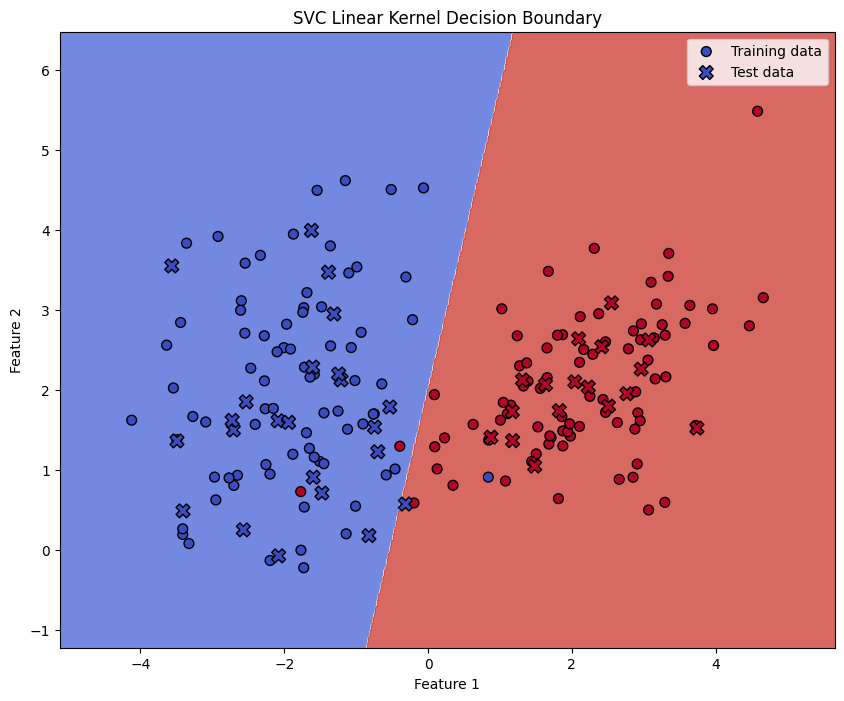

In [2]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 8))

# Create a mesh to plot in
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# Plot the decision boundary. For that, we will assign a color to each
# point in the mesh [x_min, x_max]x[y_min, y_max].
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])

# Put the result into a color plot
Z = Z.reshape(xx.shape)
plt.contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.8)

# Plot the training points
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=plt.cm.coolwarm, s=50, edgecolors='k', label='Training data')

# Plot the test points
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap=plt.cm.coolwarm, marker='X', s=100, edgecolors='k', label='Test data')

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('SVC Linear Kernel Decision Boundary')
plt.legend()
plt.show()

In [3]:
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# generate data
X, y = make_moons(n_samples = 300, noise = 0.2, random_state = 42)

# train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y,
	test_size = 0.2, random_state = 42)

# train the RBF Kernel SVM
rbf_model = SVC(kernel = 'rbf', C = 1.0, gamma = 'scale')
rbf_model.fit(X_train, y_train)

# predictions and accuracy
y_pred = rbf_model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.9833333333333333
              precision    recall  f1-score   support

           0       1.00      0.96      0.98        26
           1       0.97      1.00      0.99        34

    accuracy                           0.98        60
   macro avg       0.99      0.98      0.98        60
weighted avg       0.98      0.98      0.98        60



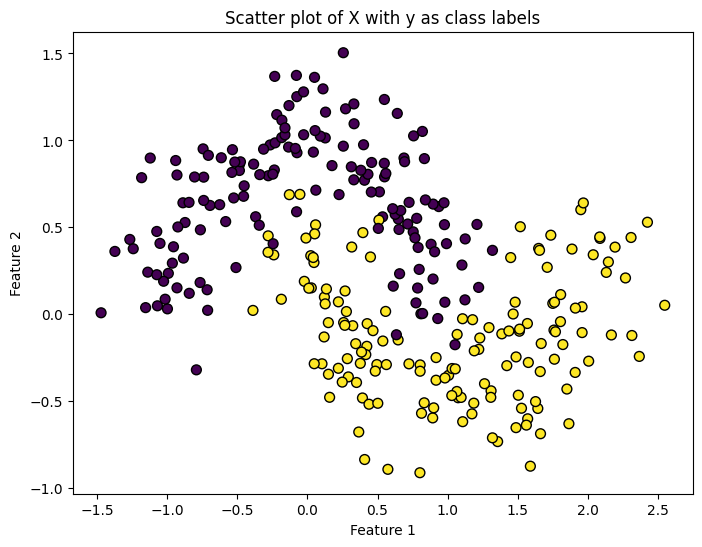

In [4]:
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', s=50, edgecolors='k')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Scatter plot of X with y as class labels')
plt.show()

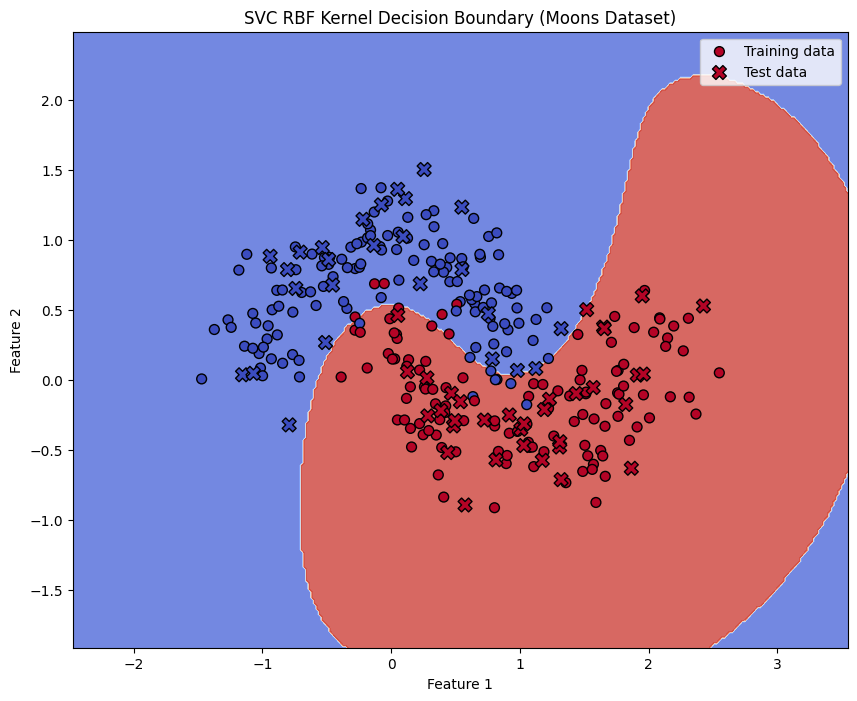

In [5]:
plt.figure(figsize=(10, 8))

# Create a mesh to plot in
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# Plot the decision boundary. For that, we will assign a color to each
# point in the mesh [x_min, x_max]x[y_min, y_max].
Z = rbf_model.predict(np.c_[xx.ravel(), yy.ravel()])

# Put the result into a color plot
Z = Z.reshape(xx.shape)
plt.contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.8)

# Plot the training points
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=plt.cm.coolwarm, s=50, edgecolors='k', label='Training data')

# Plot the test points
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap=plt.cm.coolwarm, marker='X', s=100, edgecolors='k', label='Test data')

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('SVC RBF Kernel Decision Boundary (Moons Dataset)')
plt.legend()
plt.show()

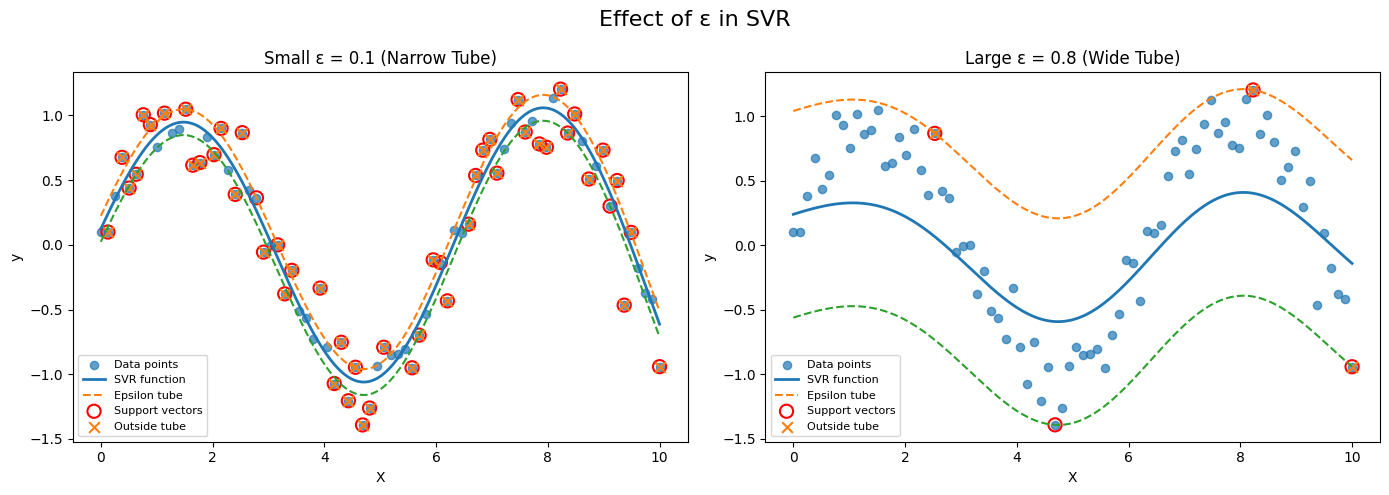

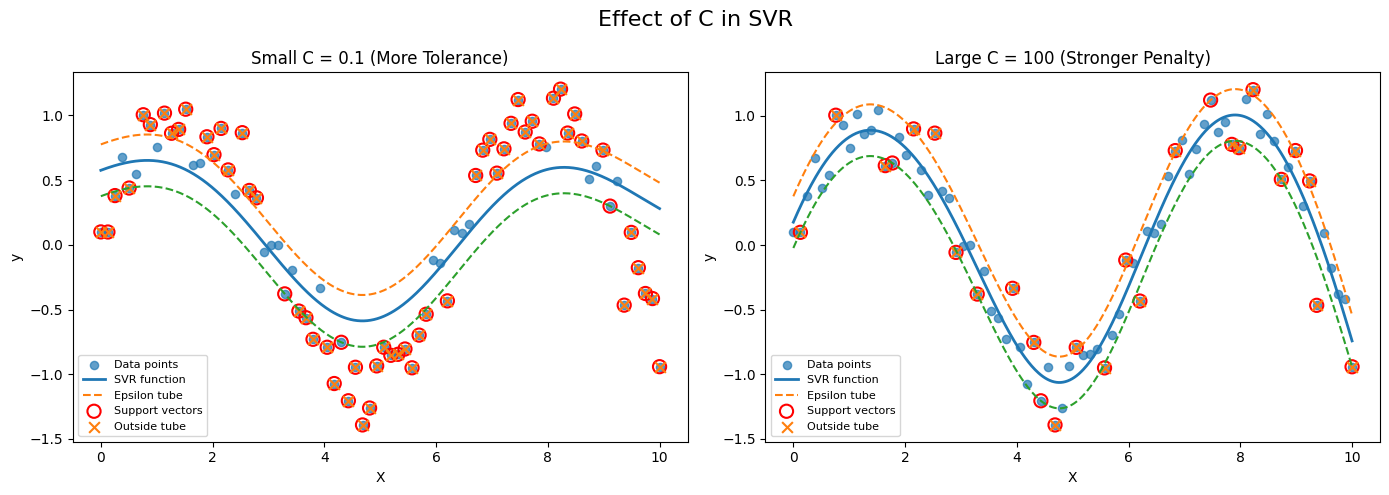

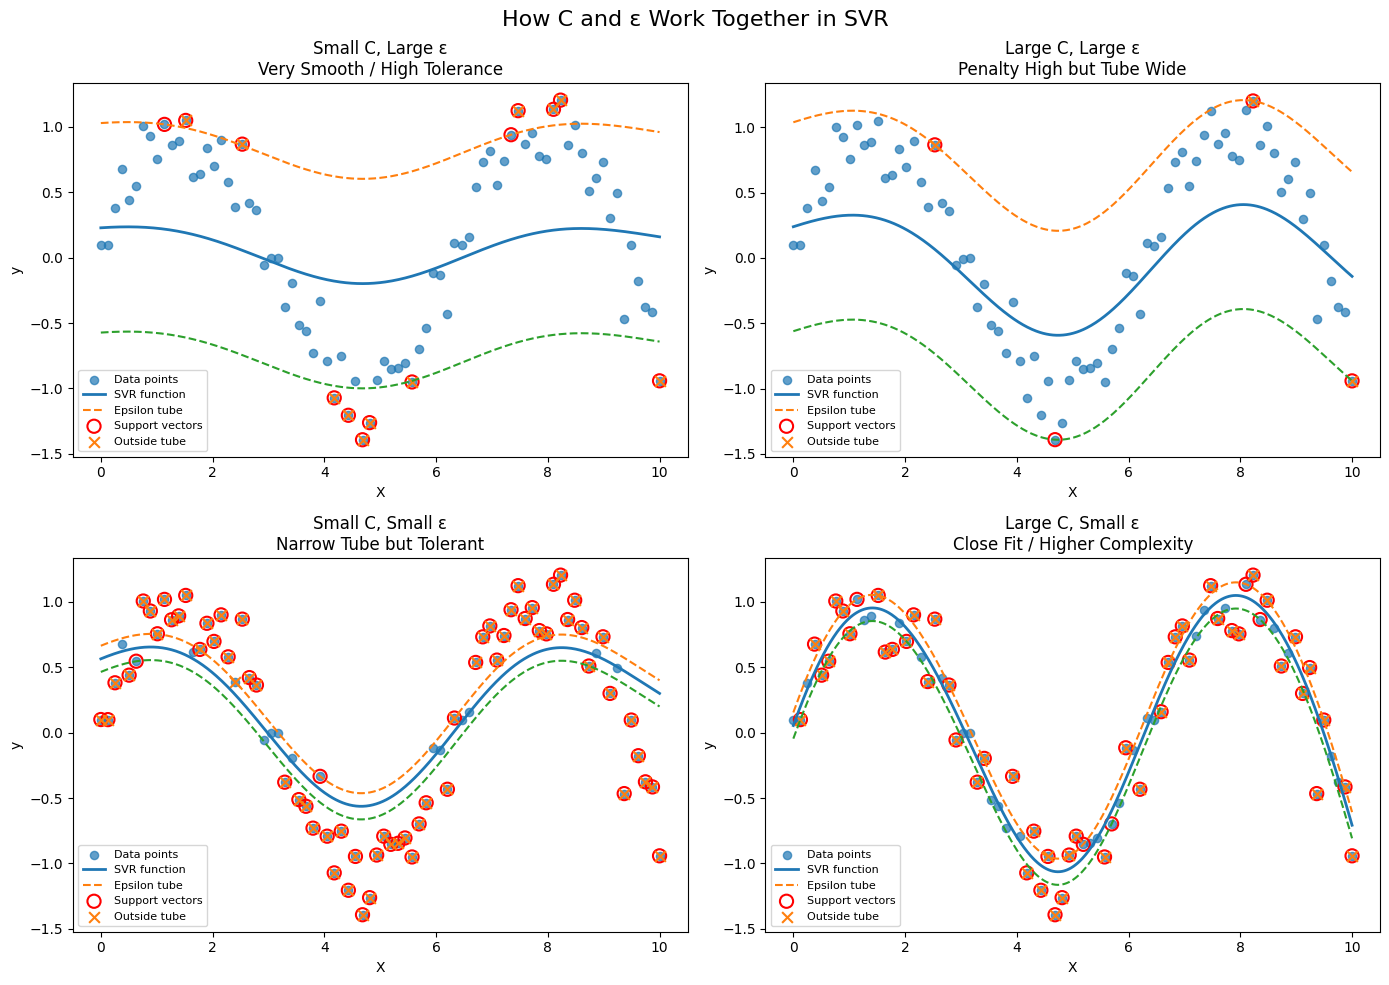

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVR

# -------------------------------
# 1. Create a synthetic dataset
# -------------------------------
np.random.seed(42)

X = np.linspace(0, 10, 80).reshape(-1, 1)
y_true = np.sin(X).ravel()
noise = np.random.normal(0, 0.2, size=len(X))
y = y_true + noise

X_plot = np.linspace(0, 10, 500).reshape(-1, 1)

# -------------------------------
# Helper function for plotting
# -------------------------------
def plot_svr(ax, C, epsilon, title):
    model = SVR(kernel='rbf', C=C, epsilon=epsilon, gamma='scale')
    model.fit(X, y)

    y_pred = model.predict(X_plot)
    y_train_pred = model.predict(X)

    # Points outside epsilon tube
    outside_tube = np.abs(y - y_train_pred) > epsilon

    ax.scatter(X, y, s=35, alpha=0.7, label='Data points')
    ax.plot(X_plot, y_pred, linewidth=2, label='SVR function')
    ax.plot(X_plot, y_pred + epsilon, linestyle='--', linewidth=1.5, label='Epsilon tube')
    ax.plot(X_plot, y_pred - epsilon, linestyle='--', linewidth=1.5)

    # Highlight support vectors
    ax.scatter(
        model.support_vectors_,
        y[model.support_],
        s=90,
        facecolors='none',
        edgecolors='red',
        linewidths=1.5,
        label='Support vectors'
    )

    # Highlight points outside epsilon tube
    ax.scatter(
        X[outside_tube],
        y[outside_tube],
        s=60,
        marker='x',
        linewidths=1.5,
        label='Outside tube'
    )

    ax.set_title(title)
    ax.set_xlabel("X")
    ax.set_ylabel("y")
    ax.legend(fontsize=8)


# -------------------------------
# 2. Effect of epsilon
# -------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_svr(axes[0], C=10, epsilon=0.1, title="Small ε = 0.1 (Narrow Tube)")
plot_svr(axes[1], C=10, epsilon=0.8, title="Large ε = 0.8 (Wide Tube)")

fig.suptitle("Effect of ε in SVR", fontsize=16)
plt.tight_layout()
plt.show()


# -------------------------------
# 3. Effect of C
# -------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_svr(axes[0], C=0.1, epsilon=0.2, title="Small C = 0.1 (More Tolerance)")
plot_svr(axes[1], C=100, epsilon=0.2, title="Large C = 100 (Stronger Penalty)")

fig.suptitle("Effect of C in SVR", fontsize=16)
plt.tight_layout()
plt.show()


# -------------------------------
# 4. Combined effect of C and epsilon
# -------------------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

settings = [
    (0.1, 0.8, "Small C, Large ε\nVery Smooth / High Tolerance"),
    (100, 0.8, "Large C, Large ε\nPenalty High but Tube Wide"),
    (0.1, 0.1, "Small C, Small ε\nNarrow Tube but Tolerant"),
    (100, 0.1, "Large C, Small ε\nClose Fit / Higher Complexity"),
]

for ax, (C, epsilon, title) in zip(axes.ravel(), settings):
    plot_svr(ax, C=C, epsilon=epsilon, title=title)

fig.suptitle("How C and ε Work Together in SVR", fontsize=16)
plt.tight_layout()
plt.show()

In [7]:
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import numpy as np

# sample dataset
X = np.array([[1], [2], [3], [4], [5], [6]])
y = np.array([1.2, 2.1, 2.9, 4.2, 5.1, 6.0])

# train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)

# create SVR model
model = SVR(kernel = 'rbf', C = 1.0, epsilon = 0.1)

# train the model
model.fit(X_train, y_train)

# make predictions
y_pred = model.predict(X_test)

# evaluate performance
print("MSE:", mean_squared_error(y_test, y_pred))


MSE: 8.01786638191539
